In [1]:
import numpy as np
import matplotlib.pyplot as plt

## all of the code is for 'Bernoulli distribution'

In [2]:
def joint_likelihood(theta, data): # if we know theta(parameter) then what is probability of getting given datas
    # theta scaler and data array
    return np.prod(np.power(theta,data)*np.power((1-theta),(1-data)))

def prior_prob(theta):  # assume uniform prior between 0 to 1
    if theta>0 and theta<1:
        return 1
    else:
        return 0

def den_inte(lh,p,dtheta):
    return np.sum(lh*p)*dtheta  # integration(likelihood*prior*dtheta)
      

In [3]:
n = 100 # no. of RVs (x1, x2, x3,...xn)
data = np.random.choice([0,1],size=n) # select n points from 0 and 1 
d_theta = 0.01
theta = np.arange(0.001,1,0.01)  # 100 theta value (parameter)

In [4]:
prior_values = [prior_prob(t) for t in theta]

In [5]:
def posterior(theta, data, prior):
    prior = np.array(prior)
    lh_all_theta = [joint_likelihood(t,data) for t in theta] # find likelihood for all 100 values of theta
    dtheta = theta[1] - theta[0]
    den = np.sum(lh_all_theta*prior)*dtheta # or we can call function 'den_inte'
    
    return (lh_all_theta*prior)/den
    

In [6]:
 a = posterior(theta , data, prior_values)

Text(0, 0.5, 'probability density')

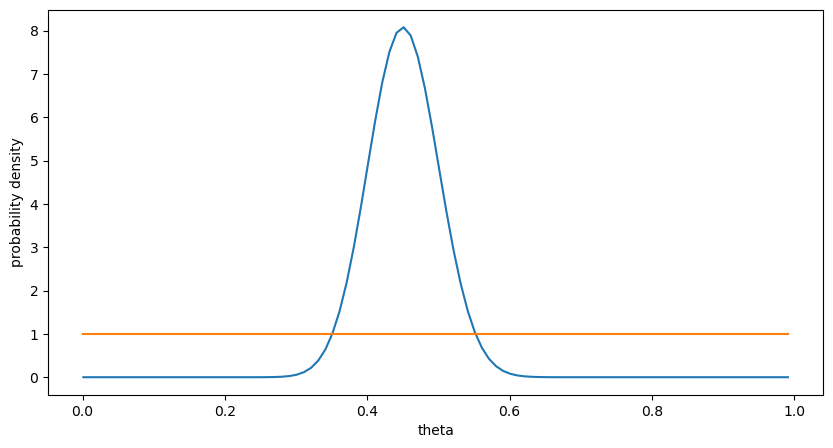

In [7]:
plt.figure(figsize = (10,5))
plt.plot(theta, a,label='posterior')
plt.plot(theta, prior_values,label='prior')
plt.xlabel('theta')
plt.ylabel('probability density')

In [8]:
def DATA(n):  # generate n no of sample bwtween 0 to 1
    return np.random.choice([0,1],size = n)

## Question 1

#### using integration

In [9]:
d10 = DATA(10)
d20 = DATA(20)
d40 = DATA(40)
d70 = DATA(70)


In [10]:
a1 = posterior(theta , d10, prior_values)
a2 = posterior(theta , d20, prior_values)
a3 = posterior(theta , d40, prior_values)
a4 = posterior(theta , d70, prior_values)

In [11]:
perameter_est1 = np.sum(a1*theta)*d_theta # n=10
perameter_est2 = np.sum(a2*theta)*d_theta # n=20
perameter_est3 = np.sum(a3*theta)*d_theta # n=40
perameter_est4 = np.sum(a4*theta)*d_theta  # n=70

In [12]:
print(perameter_est1,perameter_est2,perameter_est3,perameter_est4)

0.41666666634832616 0.4090909090909049 0.5476190476190477 0.4583333333333334


#### book answer

##### {(sum of data) + 1}/(no_ of data point + 2)

In [13]:
book_est1 = (np.sum(d10) + 1) / (len(d10) + 2) 
book_est2 = (np.sum(d20) + 1) / (len(d20) + 2) 
book_est3 = (np.sum(d40) + 1) / (len(d40) + 2)
book_est4 = (np.sum(d70) + 1) / (len(d70) + 2) 

In [14]:
print(book_est1,book_est2,book_est3,book_est4)

0.4166666666666667 0.4090909090909091 0.5476190476190477 0.4583333333333333


###

## Question 2

In [15]:
def new_prior(theta):
    if theta>0.4 and theta<0.6:
        return 5
    else:
        return 0

In [16]:
theta_ = np.linspace(0.01,0.999,100)
new_prior_values = [new_prior(t) for t in theta_]

In [17]:
new_prior_values;

In [18]:
b1 = posterior(theta_, DATA(5), new_prior_values)
b2 = posterior(theta_, DATA(10), new_prior_values)
b3 = posterior(theta_, DATA(20), new_prior_values)

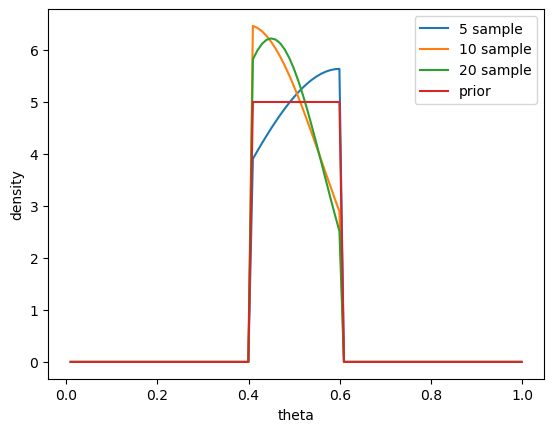

In [19]:
plt.figure()
plt.plot(theta_,b1,label='5 sample')
plt.plot(theta_,b2,label='10 sample')
plt.plot(theta_,b3,label='20 sample')
plt.plot(theta_,new_prior_values, label='prior')
plt.xlabel('theta')
plt.ylabel('density')
plt.legend()


#### It is a very short range prior , it is like we alredy know the parameter but in really we don't. 
#### So if actually the parameter is out of this range by bayesian approach we could never predict it . So we have to use a large enough prior for prediction by bayesian approach so all values are captured .  

### 

## Question 3

In [20]:
new_data = np.random.binomial(1,0.7,100 ) # take probability of head as 0.7 for 1 coin and do experiment 100 times
new_data

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0])

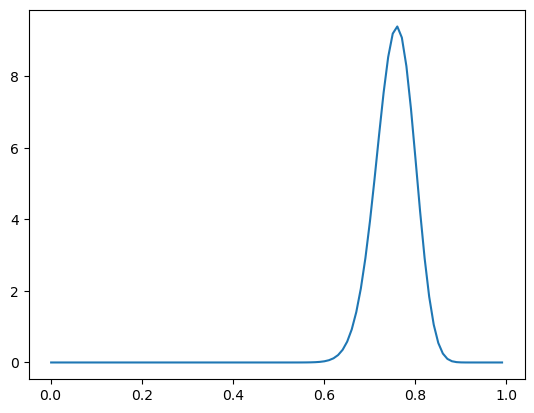

In [21]:
c = posterior(theta,new_data,prior_values)
plt.plot(theta,c)

In [22]:
book_est = (np.sum(new_data) + 1) / (len(data) + 2) 
book_est

0.7549019607843137